In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [21]:
df["Дата"] = pd.to_datetime(df["Дата"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [22]:
grouped_df = df.groupby("Дата")["Количество"].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [23]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

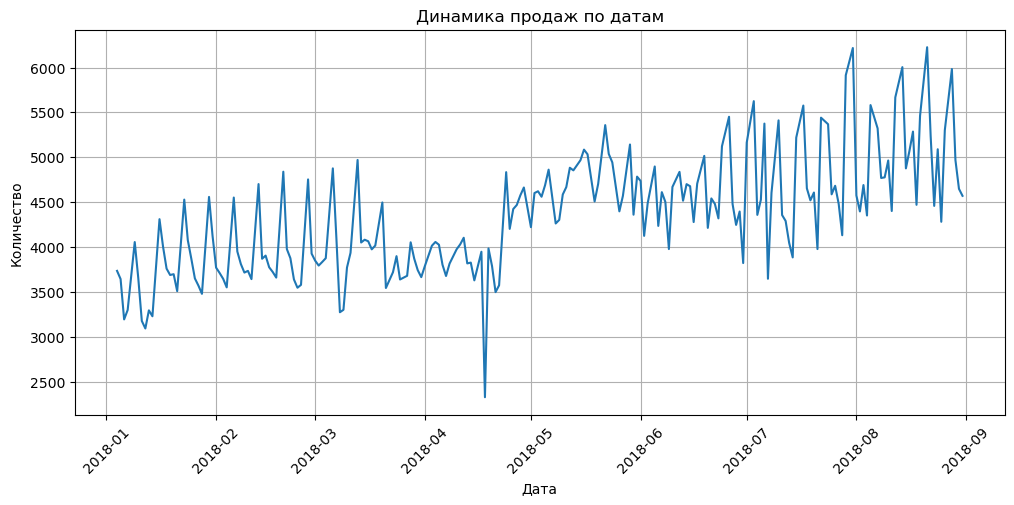

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(grouped_df["Дата"], grouped_df["Количество"])

plt.xlabel("Дата")
plt.ylabel("Количество")
plt.title("Динамика продаж по датам")

plt.xticks(rotation=45)
plt.grid()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [25]:
На графике показана динамика количества продаж по датам за период с января по август 2018 года.
В целом видно, что продажи имеют восходящий тренд: в начале периода значения чаще находятся примерно в диапазоне 3200–4500, 
а ближе к лету и августу продажи чаще поднимаются до 4500–6000.
В январе–марте наблюдаются регулярные колебания: продажи то растут, то снижаются, но в среднем держатся около 3500–4500. 
В апреле виден заметный провал продаж — есть день, где количество резко падает примерно до 2300. Это можно считать выраженным выбросом.
После апреля происходит заметный рост: с конца апреля–мая уровень продаж становится выше, примерно 4300–5200. 
Летом колебания становятся сильнее: есть как резкие падения, так и высокие пики. 
В июле–августе достигаются максимальные значения продаж, местами выше 6000.
Таким образом, можно сделать вывод, что продажи со временем растут, но распределены неравномерно. 
На графике есть сезонность/периодические колебания, а также отдельные выбросы: резкое падение в апреле и несколько высоких пиков в июле–августе.

SyntaxError: invalid character '–' (U+2013) (4203298198.py, line 2)

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [26]:
max_row = df.loc[df["Количество"].idxmax()]

display(max_row)



Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [27]:
# Добавляем месяц и день недели, если ещё не добавляли
df["Месяц"] = df["Дата"].dt.month
df["День_недели"] = df["Дата"].dt.day_name()

# Фильтруем: склад 3, месяцы июнь-июль-август, только среда
filtered_df = df[
    (df["Склад"] == 3) &
    (df["Месяц"].isin([6, 7, 8])) &
    (df["День_недели"] == "Wednesday")
]

# Группируем по месяцу и товару
month_products = filtered_df.groupby(
    ["Месяц", "Номенклатура"]
)["Количество"].sum().reset_index()

# Сортируем внутри каждого месяца по продажам
month_products = month_products.sort_values(
    ["Месяц", "Количество"],
    ascending=[True, False]
)

display(month_products.head(20))

#Теперь найдём топовый товар в каждом месяце:

top_by_month = month_products.loc[
    month_products.groupby("Месяц")["Количество"].idxmax()
]

display(top_by_month)

month_names = {
    6: "Июнь",
    7: "Июль",
    8: "Август"
}

top_by_month["Месяц_название"] = top_by_month["Месяц"].map(month_names)

display(top_by_month[["Месяц_название", "Номенклатура", "Количество"]])

,Месяц,Номенклатура,Количество
1,6,product_1,616
12,6,product_2,610
0,6,product_0,399
17,6,product_3,277
20,6,product_6,187
19,6,product_5,145
15,6,product_22,142
18,6,product_4,140
5,6,product_13,76
7,6,product_15,68


,Месяц,Номенклатура,Количество
1,6,product_1,616
24,7,product_1,696
47,8,product_1,955


,Месяц_название,Номенклатура,Количество
1,Июнь,product_1,616
24,Июль,product_1,696
47,Август,product_1,955


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [28]:
import pandas as pd
!pip install xlrd

weather = pd.read_excel("weather.xls", skiprows=6)

display(weather.head())
print(weather.columns)

#Дальше оставляем дату и температуру

weather = pd.read_excel("weather.xls", skiprows=6)

weather = weather[["Местное время в Астане", "T"]]

display(weather.head())
#Преобразуем дату
weather["Местное время в Астане"] = pd.to_datetime(
    weather["Местное время в Астане"],
    dayfirst=True,
    errors="coerce"
)

weather.head()
#Создаём отдельную колонку с датой без времени
weather["Дата"] = weather["Местное время в Астане"].dt.date

weather.head()
#Считаем среднюю температуру за день
weather_daily = weather.groupby("Дата")["T"].mean().reset_index()

weather_daily["Дата"] = pd.to_datetime(weather_daily["Дата"])

display(weather_daily.head())

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3,12.0,NaN,NaN,NaN,NaN


Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')


,Местное время в Астане,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [29]:
# создаём grouped_df заново
grouped_df = df.groupby("Дата")["Количество"].sum().reset_index()

# переименуем столбец для удобства
grouped_df = grouped_df.rename(columns={"Количество": "Количество_продаж"})

display(grouped_df.head())
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])
weather_daily["Дата"] = pd.to_datetime(weather_daily["Дата"])

merged_df = grouped_df.merge(weather_daily, on="Дата", how="inner")

display(merged_df.head())
print(merged_df.shape)

,Дата,Количество_продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


,Дата,Количество_продаж,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


(205, 3)


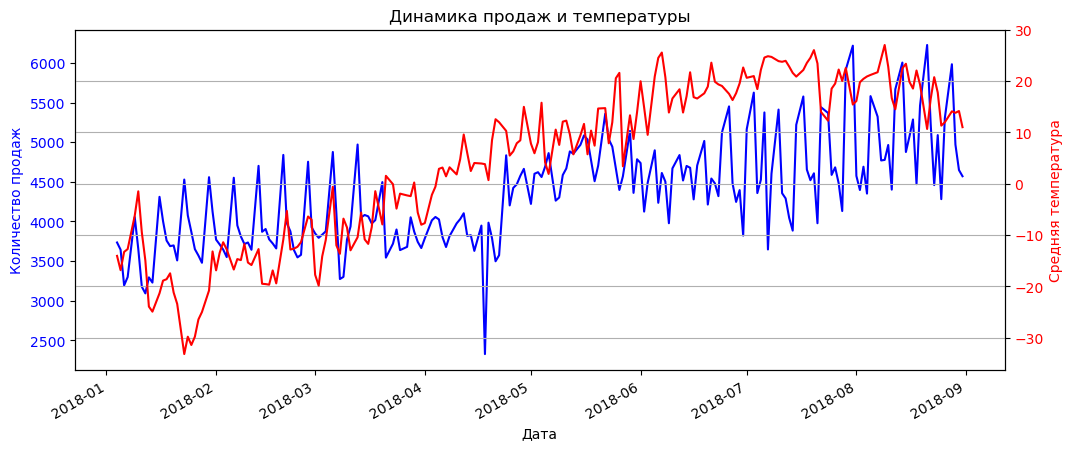

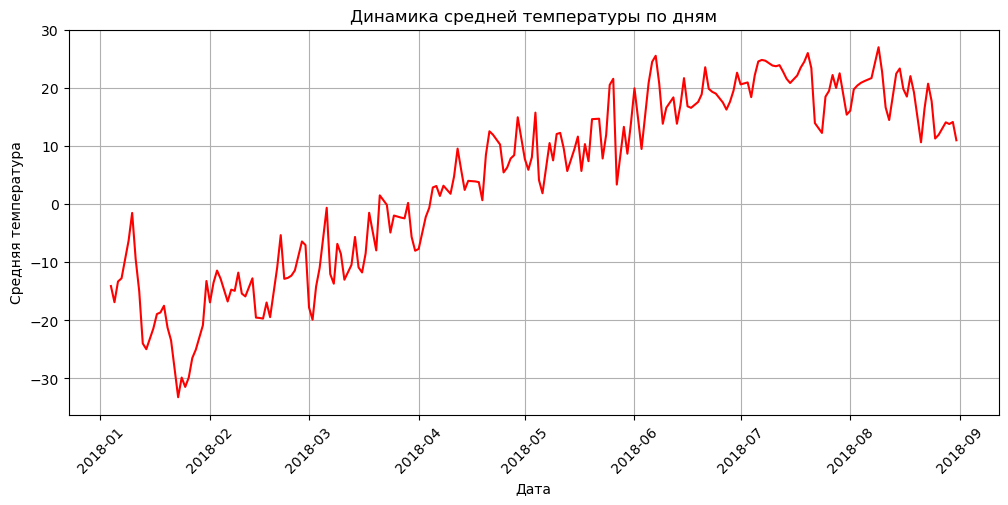

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# первая ось — продажи
ax1.plot(
    merged_df["Дата"], 
    merged_df["Количество_продаж"], 
    color="blue", 
    label="Количество продаж"
)
ax1.set_xlabel("Дата")
ax1.set_ylabel("Количество продаж", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# вторая ось — температура
ax2 = ax1.twinx()
ax2.plot(
    merged_df["Дата"], 
    merged_df["T"], 
    color="red", 
    label="Температура"
)
ax2.set_ylabel("Средняя температура", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Динамика продаж и температуры")
fig.autofmt_xdate()
plt.grid()

plt.show()


plt.figure(figsize=(12, 5))

plt.plot(merged_df["Дата"], merged_df["T"], color="red")

plt.xlabel("Дата")
plt.ylabel("Средняя температура")
plt.title("Динамика средней температуры по дням")

plt.xticks(rotation=45)
plt.grid()

plt.show()